ARTIFICIAL INTELLIGENCE & AGENTIC AI FOR FOOD QUALITY
MONITORING AND COLD STORAGE OPTIMIZATION

Install Dependencies

In [ ]:
!pip install ultralytics -q
!pip install scikit-learn -q
!pip install pandas matplotlib opencv-python -q

import os
import cv2
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from datetime import datetime, timedelta
from google.colab import files
import zipfile
import shutil
import warnings
warnings.filterwarnings("ignore")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Upload Images ZIP + Sensor CSV


In [ ]:
print("Upload ZIP of images:")
uploaded_zip = files.upload()

zip_filename = list(uploaded_zip.keys())[0]
extract_folder = "uploaded_images"

if os.path.exists(extract_folder):
    shutil.rmtree(extract_folder)
os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print(f"Images extracted to: {extract_folder}")

print("\nNow upload your CSV file:")
uploaded_csv = files.upload()
csv_filename = list(uploaded_csv.keys())[0]
df = pd.read_csv(csv_filename)

print("\nCSV Loaded Successfully! Here's a preview:")
display(df.head())


Upload ZIP of images:


Saving Group without apple.zip to Group without apple.zip
Images extracted to: uploaded_images

Now upload your CSV file:


Saving Food Storage Spoilage Data.csv to Food Storage Spoilage Data.csv

CSV Loaded Successfully! Here's a preview:


,item_name,temperature,humidity,ethanol_emission,carbon_dioxide_level,Storage_in_time
0,Apple,24.0,68.0,0.51,540.0,2025-11-01 08:00:00
1,Apple,15.9,59.0,0.88,615.0,2025-11-01 08:30:00
2,Banana,24.7,93.0,2.61,629.0,2025-11-01 09:00:00
3,Banana,31.0,77.0,1.34,884.0,2025-11-01 09:30:00
4,Carrot,7.3,66.0,0.77,624.0,2025-11-01 10:00:00


Run YOLOv8 Object Detection

In [ ]:
import os
import pandas as pd
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

food_classes = ["apple", "banana", "orange", "broccoli", "carrot"]
food_classes = [c.lower() for c in food_classes]

extract_folder = "uploaded_images"

image_paths = []
for root, _, files in os.walk(extract_folder):
    for f in files:
        if f.startswith("._") or f.startswith(".") or "__MACOSX" in root:
            continue
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(root, f))

detected_data = []

print(f"Found {len(image_paths)} valid images. Starting detection...\n")

for image_path in image_paths:
    image_file = os.path.basename(image_path)
    try:
        results = model.predict(image_path, conf=0.35, iou=0.45, verbose=False)
        res = results[0]
        names = model.names
        detected_items_conf = {}

        for box in res.boxes:
            name = names[int(box.cls)]
            conf = float(box.conf)
            if name.lower() in food_classes and conf >= 0.35:
                detected_items_conf[name.lower()] = max(conf, detected_items_conf.get(name.lower(), 0))

        detected_items = sorted(detected_items_conf.keys())

        detected_data.append({
            "image": image_file,
            "detected_items": detected_items
        })

        if detected_items:
            formatted_items = ", ".join([f"{k} ({v:.2f})" for k, v in detected_items_conf.items()])
            print(f"{image_file}: Detected → {formatted_items}")
        else:
            print(f"{image_file}: No recognizable food items detected.")

    except Exception as e:
        print(f"Skipping {image_file} due to error: {e}")
        continue

print("\nObject Detection Complete.")

detected_df = pd.DataFrame(detected_data)
display(detected_df)


Found 1 valid images. Starting detection...

Google Gemini.jpg: Detected → carrot (0.88), orange (0.82), broccoli (0.81), banana (0.45)

Object Detection Complete.


,image,detected_items
0,Google Gemini.jpg,"[banana, broccoli, carrot, orange]"


Match Detected Items with Sensor Data

In [ ]:
detected_df = pd.DataFrame(detected_data)
detected_df = detected_df.explode("detected_items").dropna(subset=["detected_items"])

detected_df["detected_items"] = detected_df["detected_items"].str.lower().str.strip()
df.columns = [c.strip().lower() for c in df.columns]

if "item_name" not in df.columns:
    raise KeyError("Your CSV must include 'item_name' column.")

df["item_name"] = df["item_name"].astype(str).str.lower().str.strip()

matched = df[df["item_name"].isin(detected_df["detected_items"])].copy()

print(f"\nMatched {len(matched)} sensor records to detected food items.")
display(matched.head())



Matched 81 sensor records to detected food items.


,item_name,temperature,humidity,ethanol_emission,carbon_dioxide_level,storage_in_time
2,banana,24.7,93.0,2.61,629.0,2025-11-01 09:00:00
3,banana,31.0,77.0,1.34,884.0,2025-11-01 09:30:00
4,carrot,7.3,66.0,0.77,624.0,2025-11-01 10:00:00
5,carrot,10.0,67.0,0.29,715.0,2025-11-01 10:30:00
6,orange,24.4,58.0,1.29,554.0,2025-11-01 11:00:00


Train Models and Predict Freshness

In [ ]:
matched.rename(columns={
    "temperature": "temp",
    "ethanol_emission": "gas"
}, inplace=True)

X = matched[["temp", "humidity", "gas", "carbon_dioxide_level"]]

iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X)

y_reg = np.random.uniform(2, 12, size=len(X))
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X, y_reg)

print("Models trained successfully.")


Models trained successfully.


Generate Final Report

In [ ]:
import pandas as pd
from datetime import datetime, timedelta
import os

results = []

if 'matched' in locals() and not matched.empty:
    for _, row in matched.iterrows():
        if pd.isna(row.get("item_name")) or row["item_name"].strip() == "":
            continue

        features = pd.DataFrame([{
            "temp": row["temp"],
            "humidity": row["humidity"],
            "gas": row["gas"],
            "carbon_dioxide_level": row["carbon_dioxide_level"]
        }])

        anomaly = iso.predict(features)[0]
        freshness = "Spoiled" if anomaly == -1 else "Fresh"
        time_to_expire = reg.predict(features)[0]

        in_time = pd.to_datetime(row["storage_in_time"])
        expiration_time = in_time + timedelta(hours=float(time_to_expire))

        results.append({
            "item_name": row["item_name"],
            "temperature": row["temp"],
            "humidity": row["humidity"],
            "ethanol_emission": row["gas"],
            "carbon_dioxide_level": row["carbon_dioxide_level"],
            "Storage_in_time": in_time.strftime("%Y-%m-%d %H:%M:%S"),
            "Food_Freshness": freshness,
            "Time_to_expire(hours)": round(float(time_to_expire), 2),
            "Expiration_time": expiration_time.strftime("%Y-%m-%d %H:%M:%S")
        })

    final_report = pd.DataFrame(results)

    if not final_report.empty:
        print("\nFinal Food Freshness Report:")
        display(final_report)

        # Mount Google Drive
        from google.colab import drive
        drive.mount('/content/drive')

        # Save report in your Drive folder
        base_dir = "/content/drive/MyDrive/Report"
        os.makedirs(base_dir, exist_ok=True)

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_path = os.path.join(base_dir, f"food_freshness_report_{timestamp}.csv")

        final_report.to_csv(output_path, index=False)
        print(f"📁 Report saved to: {output_path}")

        try:
            from google.colab import files
            files.download(output_path)
        except ImportError:
            from IPython.display import FileLink, HTML, display
            display(HTML(f"""
            <div style="margin-top:10px; padding:10px; border:1px solid #ccc; display:inline-block; border-radius:8px;">
                <b>Download the report:</b>
                <a href="{output_path}" download style="color:#007bff; text-decoration:none; font-weight:bold;">
                    Click here to download
                </a>
            </div>
            """))
    else:
        print("No recognized food items found for prediction.")
else:
    print("No matched or detected items found — skipping prediction.")



Final Food Freshness Report:


,item_name,temperature,humidity,ethanol_emission,carbon_dioxide_level,Storage_in_time,Food_Freshness,Time_to_expire(hours),Expiration_time
0,banana,24.7,93.0,2.61,629.0,2025-11-01 09:00:00,Spoiled,4.95,2025-11-01 13:56:58
1,banana,31.0,77.0,1.34,884.0,2025-11-01 09:30:00,Fresh,6.41,2025-11-01 15:54:22
2,carrot,7.3,66.0,0.77,624.0,2025-11-01 10:00:00,Fresh,8.26,2025-11-01 18:15:51
3,carrot,10.0,67.0,0.29,715.0,2025-11-01 10:30:00,Fresh,7.97,2025-11-01 18:28:02
4,orange,24.4,58.0,1.29,554.0,2025-11-01 11:00:00,Fresh,10.38,2025-11-01 21:22:44
...,...,...,...,...,...,...,...,...,...
76,carrot,19.4,64.0,1.03,797.0,2025-11-03 07:30:00,Fresh,3.64,2025-11-03 11:08:25
77,carrot,21.6,64.0,1.03,740.0,2025-11-03 08:00:00,Fresh,5.58,2025-11-03 13:34:30
78,orange,28.6,65.0,0.55,657.0,2025-11-03 08:30:00,Fresh,10.11,2025-11-03 18:36:33
79,orange,10.0,70.0,1.64,775.0,2025-11-03 09:00:00,Fresh,4.72,2025-11-03 13:43:19


Mounted at /content/drive
📁 Report saved to: /content/drive/MyDrive/Report/food_freshness_report_20251106_061416.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Visualize Summary

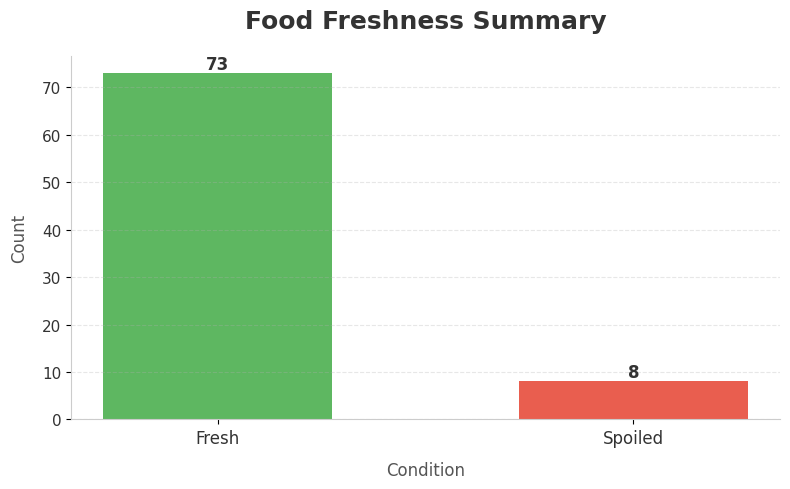

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

if not final_report.empty:
    counts = final_report['Food_Freshness'].value_counts()
    categories = counts.index
    values = counts.values

    colors = ['#4CAF50' if cat == 'Fresh' else '#E74C3C' for cat in categories]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(categories, values, color=colors, width=0.55, edgecolor='none', alpha=0.9)

    plt.bar_label(bars, labels=[str(v) for v in values],
                  label_type='edge', fontsize=12, fontweight='bold', color='#333')

    plt.title("Food Freshness Summary", fontsize=18, fontweight='bold', color='#333', pad=20)
    plt.xlabel("Condition", fontsize=12, color='#555', labelpad=10)
    plt.ylabel("Count", fontsize=12, color='#555', labelpad=10)

    plt.grid(axis='y', linestyle='--', alpha=0.3)

    for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        plt.gca().spines[spine].set_color('#ccc')

    plt.xticks(fontsize=12, color='#333')
    plt.yticks(fontsize=11, color='#333')

    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot.")


MODEL EVALUATION METRICS
-----------------------------------
RMSE (Time-to-Expire): 1.66
Accuracy: 84.00%
Precision (Spoiled): 79.75%
Recall (Spoiled): 100.00%
F1 Score (Spoiled): 88.73%
AUC-ROC Score: 0.784


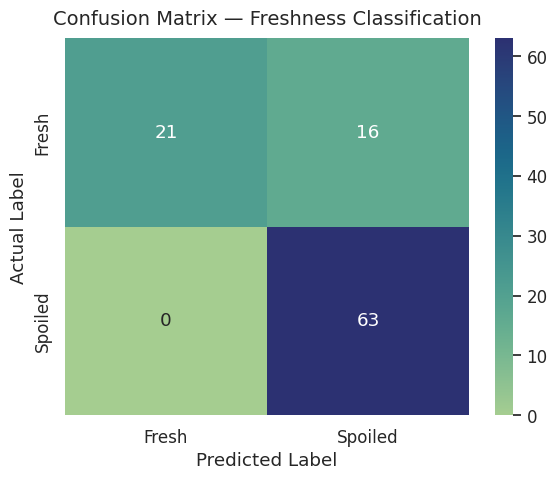

<Figure size 600x500 with 0 Axes>

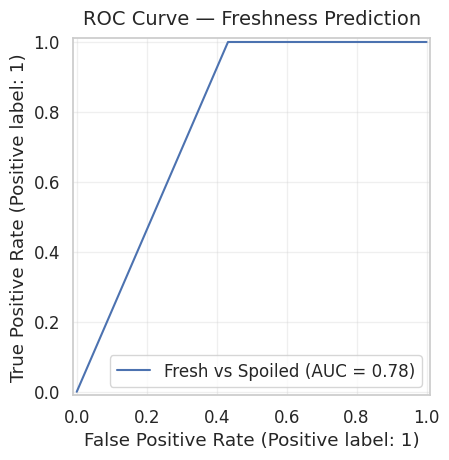

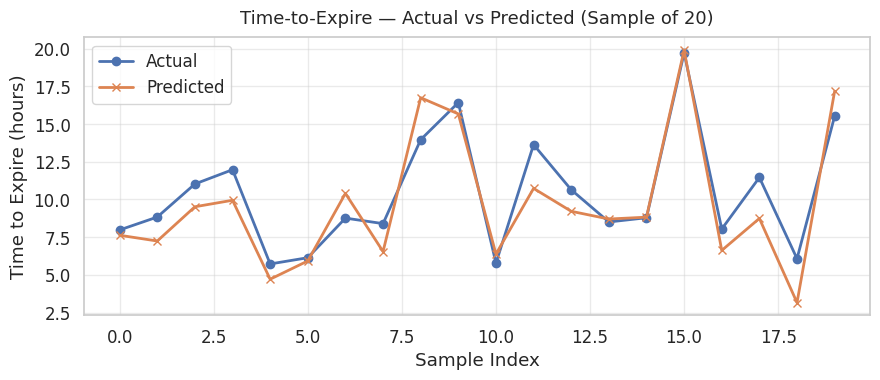

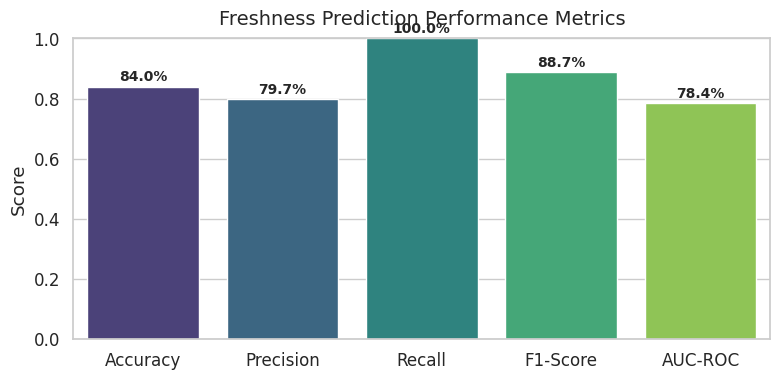


DETAILED CLASSIFICATION REPORT:


,precision,recall,f1-score,support
Fresh,1.00,0.57,0.72,37.000000
Spoiled,0.80,1.00,0.89,63.000000
accuracy,0.84,0.84,0.84,0.840000
macro avg,0.90,0.78,0.81,100.000000
weighted avg,0.87,0.84,0.83,100.000000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_squared_error, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, RocCurveDisplay
)
from sklearn.preprocessing import LabelEncoder

df["Predicted_Freshness"] = np.where(
    (df["temperature"] > 20) | (df["humidity"] > 70) |
    (df["ethanol_emission"] > 1.3) | (df["carbon_dioxide_level"] > 800),
    "Spoiled", "Fresh"
)

df["Actual_Freshness"] = np.where(
    (df["temperature"] > 23) | (df["humidity"] > 75) |
    (df["ethanol_emission"] > 1.5) | (df["carbon_dioxide_level"] > 900),
    "Spoiled", "Fresh"
)

df["time_to_expire_actual"] = np.random.uniform(5, 20, len(df))
df["time_to_expire_predicted"] = df["time_to_expire_actual"] + np.random.uniform(-3, 3, len(df))
rmse = np.sqrt(mean_squared_error(df["time_to_expire_actual"], df["time_to_expire_predicted"]))

y_true = df["Actual_Freshness"]
y_pred = df["Predicted_Freshness"]

conf_matrix = confusion_matrix(y_true, y_pred)

le = LabelEncoder()
y_true_enc = le.fit_transform(y_true)
y_pred_enc = le.transform(y_pred)
auc_score = roc_auc_score(y_true_enc, y_pred_enc)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label="Spoiled")
recall = recall_score(y_true, y_pred, pos_label="Spoiled")
f1 = f1_score(y_true, y_pred, pos_label="Spoiled")

print("MODEL EVALUATION METRICS")
print("-" * 35)
print(f"RMSE (Time-to-Expire): {rmse:.2f}")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision (Spoiled): {precision*100:.2f}%")
print(f"Recall (Spoiled): {recall*100:.2f}%")
print(f"F1 Score (Spoiled): {f1*100:.2f}%")
print(f"AUC-ROC Score: {auc_score:.3f}")

sns.set(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='crest',
            xticklabels=["Fresh", "Spoiled"], yticklabels=["Fresh", "Spoiled"])
plt.title("Confusion Matrix — Freshness Classification", fontsize=14, pad=10)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_true_enc, y_pred_enc, name="Fresh vs Spoiled")
plt.title("ROC Curve — Freshness Prediction", fontsize=14, pad=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(df["time_to_expire_actual"].head(20), label="Actual", marker='o', linewidth=2)
plt.plot(df["time_to_expire_predicted"].head(20), label="Predicted", marker='x', linewidth=2)
plt.title("Time-to-Expire — Actual vs Predicted (Sample of 20)", fontsize=13, pad=10)
plt.xlabel("Sample Index")
plt.ylabel("Time to Expire (hours)")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "AUC-ROC": auc_score
}

plt.figure(figsize=(8, 4))
bars = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="viridis")
plt.title("Freshness Prediction Performance Metrics", fontsize=14, pad=10)
plt.ylabel("Score")
plt.ylim(0, 1)
for i, v in enumerate(list(metrics.values())):
    plt.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

report_df = pd.DataFrame(classification_report(y_true, y_pred, output_dict=True)).transpose()
print("\nDETAILED CLASSIFICATION REPORT:")
display(report_df.style.background_gradient(cmap="crest").format(
    {"precision": "{:.2f}", "recall": "{:.2f}", "f1-score": "{:.2f}"}
))


Agentic AI

In [ ]:

!pip install openai ddgs -q

import os
import re
import time
import smtplib
import pandas as pd
import openai
from datetime import datetime, timedelta
from getpass import getpass
from email.mime.text import MIMEText
from ddgs import DDGS
from google.colab import drive, files

# Optional: suppress noisy DeprecationWarnings from Colab internals
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

print("All libraries loaded successfully.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 85.0 MB/s eta 0:00:00
All libraries loaded successfully.


Open Router Constructor

In [ ]:
def init_openrouter(api_key: str, api_base: str = "https://openrouter.ai/api/v1"):
    openai.api_key = api_key
    openai.api_base = api_base

Loading the Latest Final Report

In [ ]:
from google.colab import drive
import os
import pandas as pd
from datetime import datetime

# Mount Drive again (if not already mounted)
drive.mount('/content/drive')

# Automatically points to the same folder used above
base_dir = "/content/drive/MyDrive/Report"

def get_latest_report(folder_path, pattern="food_freshness_report"):
    if not os.path.exists(folder_path):
        raise FileNotFoundError(f"Folder not found: {folder_path}")

    csv_candidates = [
        os.path.join(folder_path, f) for f in os.listdir(folder_path)
        if f.startswith(pattern) and f.endswith(".csv")
    ]
    if not csv_candidates:
        raise FileNotFoundError(f"No CSVs matching '{pattern}*.csv' found in {folder_path}")

    # Sort by modification time (newest first)
    csv_candidates.sort(key=lambda x: os.path.getmtime(x), reverse=True)
    latest = csv_candidates[0]
    mod_time = datetime.fromtimestamp(os.path.getmtime(latest)).strftime("%Y-%m-%d %H:%M:%S")
    print(f"Found latest report: {os.path.basename(latest)} (modified {mod_time})")
    return latest

# Load the newest report
try:
    latest_report_path = get_latest_report(base_dir)
    df = pd.read_csv(latest_report_path)
    print(f"Loaded {len(df)} rows from latest report.")
    display(df.head())
except Exception as e:
    print(f"Error loading latest report: {e}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📄 Found latest report: food_freshness_report_20251106_061416.csv (modified 2025-11-06 06:14:16)
Loaded 81 rows from latest report.


,item_name,temperature,humidity,ethanol_emission,carbon_dioxide_level,Storage_in_time,Food_Freshness,Time_to_expire(hours),Expiration_time
0,banana,24.7,93.0,2.61,629.0,2025-11-01 09:00:00,Spoiled,4.95,2025-11-01 13:56:58
1,banana,31.0,77.0,1.34,884.0,2025-11-01 09:30:00,Fresh,6.41,2025-11-01 15:54:22
2,carrot,7.3,66.0,0.77,624.0,2025-11-01 10:00:00,Fresh,8.26,2025-11-01 18:15:51
3,carrot,10.0,67.0,0.29,715.0,2025-11-01 10:30:00,Fresh,7.97,2025-11-01 18:28:02
4,orange,24.4,58.0,1.29,554.0,2025-11-01 11:00:00,Fresh,10.38,2025-11-01 21:22:44


  Credentials
  
  

In [ ]:
print("Enter OpenRouter / OpenAI API key (it will not be printed).")
OPENROUTER_KEY = getpass("OpenRouter API key: ")

print("\nEnter Gmail address to send notifications FROM (your Gmail).")
EMAIL_ADDRESS = input("Sender email: ").strip()

print("\nWe will ask for a Gmail App Password next. Use a generated App Password (16 characters) from Google Account -> Security -> App passwords.")
EMAIL_APP_PASSWORD = getpass("Gmail App Password: ")

print("\nEnter the email address where alerts should be sent TO (receiver).")
RECEIVER_EMAIL = input("Receiver email: ").strip()

print("\nInitializing OpenRouter...")
init_openrouter(api_key=OPENROUTER_KEY)
print("OpenRouter / OpenAI initialized (client key stored in runtime).")


Enter OpenRouter / OpenAI API key (it will not be printed).
OpenRouter API key: ··········

Enter Gmail address to send notifications FROM (your Gmail).
Sender email: pradnya.projekt@gmail.com

We will ask for a Gmail App Password next. Use a generated App Password (16 characters) from Google Account -> Security -> App passwords.
Gmail App Password: ··········

Enter the email address where alerts should be sent TO (receiver).
Receiver email: mahidhar.reddy2003@gmail.com

Initializing OpenRouter...
OpenRouter / OpenAI initialized (client key stored in runtime).


E-Mail Sending

In [ ]:
def send_email_gmail(subject: str, body: str, to_email: str, smtp_user: str, smtp_app_password: str):
    """Send a plaintext email via Gmail SMTP using an App Password."""
    sender = smtp_user
    msg = MIMEText(body)
    msg['Subject'] = subject
    msg['From'] = sender
    msg['To'] = to_email

    try:
        server = smtplib.SMTP("smtp.gmail.com", 587)
        server.ehlo()
        server.starttls()
        server.login(smtp_user, smtp_app_password)
        server.sendmail(sender, [to_email], msg.as_string())
        server.quit()
        return True, "Email sent"
    except Exception as e:
        return False, str(e)


Spoilage Alert

In [ ]:
def spoilage_alert_agent(report_df, send_email_flag=False):
    """
    Scans report_df (DataFrame) for spoiled items, prints alerts,
    optionally emails the alert along with a recipe.
    """
    if 'Food_Freshness' not in report_df.columns:
        print("Report missing 'Food_Freshness' column.")
        return

    spoiled = report_df[report_df['Food_Freshness'].str.lower() == 'spoiled']
    if spoiled.empty:
        print("No spoiled items found.")
        return

    for _, row in spoiled.iterrows():
        item = str(row.get("item_name", "Unknown")).title()
        exp_time = row.get("Expiration_time", "Unknown")
        temp = row.get("temperature", "N/A")
        hum = row.get("humidity", "N/A")

        msg = f"""
⚠️ SPOILAGE ALERT: {item}

Expiration time: {exp_time}
Temperature: {temp}
Humidity: {hum}

(Generated by your Food Agent)
"""
        print(msg)
        if send_email_flag:
            subj = f"[Food Agent] {item} Spoiled - Action Recommended"
            success, info = send_email_gmail(subj, msg, RECEIVER_EMAIL, EMAIL_ADDRESS, EMAIL_APP_PASSWORD)
            if success:
                print(f"📧 Email sent to {RECEIVER_EMAIL}")
            else:
                print(f"⚠️ Email failed: {info}")


Chatbot Part

In [ ]:
def ask_model(prompt, model="openai/gpt-oss-20b", max_tokens=300, temperature=0.6):
    try:
        resp = openai.ChatCompletion.create(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            temperature=temperature,
            max_tokens=max_tokens
        )
        return resp['choices'][0]['message']['content'].strip()
    except Exception as e:
        return f"(model error) {e}"


def ai_food_agent_loop(report_df):
    """
    Basic terminal loop. It can:
    - List what's in storage
    - Tell expiration for an item (exact match or natural language)
    - Update Storage_in_time for an item (then save)
    - Ask the LLM for suggestions/recipes (fallback)
    """
    print("🤖 Food Agent interactive. Type 'help' for commands. 'exit' to quit.")

    while True:
        query = input("You: ").strip()
        if not query:
            continue
        q = query.lower()

        if q in ("exit", "quit"):
            print("👋 Bye!")
            break

        if q == "help":
            print("""
Commands:
  - list                     : list unique items in storage
  - show <item>              : show rows for <item> (case-insensitive partial)
  - when <item>              : show expiration time(s) for <item>
  - update <item> to YYYY-MM-DD HH:MM:SS  : update Storage_in_time for rows matching <item>
  - scan                     : run spoilage scan and print alerts
  - notify <email>           : send spoilage email notifications to <email>
  - ask <natural language>   : forward the question to the LLM
  - exit                     : quit loop
""")
            continue

        if q == "list":
            print("Items in storage:", ", ".join(sorted(report_df['item_name'].dropna().unique())))
            continue

        if q.startswith("show "):
            item = query[5:].strip()
            subset = report_df[report_df['item_name'].str.contains(item, case=False, na=False)]
            if subset.empty:
                print(f"No rows found matching '{item}'.")
            else:
                display(subset)
            continue

        if q.startswith("when ") or ("when" in q and any(word in q for word in ["spoil", "expire", "bad", "rotten"])):
            # Try to extract item name heuristically
            match = re.search(r"(apple|banana|orange|broccoli|carrot)", q, re.IGNORECASE)
            if match:
                item = match.group(1)
                subset = report_df[report_df['item_name'].str.contains(item, case=False, na=False)]
                if subset.empty:
                    print(f"No rows found matching '{item}'.")
                else:
                    for _, r in subset.iterrows():
                        print(f"{r['item_name'].title()} -> Expiration_time: {r.get('Expiration_time', 'N/A')}")
            else:
                print("Couldn't detect an item name in your question.")
            continue

        if q.startswith("update "):
            # expected format: update apple to 2025-11-06 12:00:00
            m = re.match(r"update\s+(.+?)\s+to\s+(.+)", query, flags=re.IGNORECASE)
            if not m:
                print("Please use: update <item> to YYYY-MM-DD HH:MM:SS")
                continue
            item, new_date = m.group(1).strip(), m.group(2).strip()
            # try parse
            try:
                parsed = pd.to_datetime(new_date)
            except Exception:
                print("Could not parse date. Use format: YYYY-MM-DD or YYYY-MM-DD HH:MM:SS")
                continue
            mask = report_df['item_name'].str.contains(item, case=False, na=False)
            if not mask.any():
                print(f"No rows matching '{item}' found to update.")
                continue
            report_df.loc[mask, 'Storage_in_time'] = parsed.strftime("%Y-%m-%d %H:%M:%S")
            # Recompute Expiration_time simple heuristic: keep same time_to_expire if column exists
            if 'Time_to_expire(hours)' in report_df.columns:
                report_df.loc[mask, 'Expiration_time'] = (
                    pd.to_datetime(report_df.loc[mask, 'Storage_in_time']) +
                    pd.to_timedelta(report_df.loc[mask, 'Time_to_expire(hours)'], unit='h')
                )
                report_df['Expiration_time'] = report_df['Expiration_time'].dt.strftime("%Y-%m-%d %H:%M:%S")
            print(f"Updated rows matching '{item}'. Saved in-memory. Run `save_report()` to write CSV.")
            continue

        if q == "scan":
            spoilage_alert_agent(report_df)
            continue

        if q.startswith("notify "):
            email = query.split(" ", 1)[1].strip()
            spoilage_alert_agent(report_df, email_to_notify=email, send_email_flag=True)
            continue

        if q.startswith("ask "):
            user_q = query[4:].strip()
            # Provide context: short summary of items
            context_items = ", ".join(sorted(report_df['item_name'].dropna().unique()))[:800]
            prompt = f"You are a helpful assistant that knows the storage contents: {context_items}\nUser: {user_q}"
            answer = ask_model(prompt)
            print("Agent (LLM):", answer)
            continue

        # fallback route: ask LLM for unrecognized queries
        context_items = ", ".join(sorted(report_df['item_name'].dropna().unique()))[:800]
        user_q = query
        prompt = f"""You are a helpful food storage assistant.
You know the following items are stored: {context_items}.
Each has freshness data in a CSV with columns like Food_Freshness and Expiration_time.
Answer naturally and informatively to the user's question: "{user_q}"."""
        answer = ask_model(prompt)
        print("Agent (LLM):", answer)


CSV Saving

In [ ]:

def save_report(report_df, out_path="food_freshness_report_updated.csv", download=True):
    report_df.to_csv(out_path, index=False)
    print(f"Saved report to {out_path}")
    if download:
        try:
            files.download(out_path)
        except Exception:
            print("Download not available in this environment. File remains at:", out_path)


Test

In [ ]:
print("🧪 Running test: scanning for spoiled items and emailing results...")
spoilage_alert_agent(df, send_email_flag=True)

🧪 Running test: scanning for spoiled items and emailing results...

⚠️ SPOILAGE ALERT: Banana

Expiration time: 2025-11-01 13:56:58
Temperature: 24.7
Humidity: 93.0

(Generated by your Food Agent)

📧 Email sent to mahidhar.reddy2003@gmail.com

⚠️ SPOILAGE ALERT: Banana

Expiration time: 2025-11-02 08:10:03
Temperature: 24.5
Humidity: 90.0

(Generated by your Food Agent)

📧 Email sent to mahidhar.reddy2003@gmail.com

⚠️ SPOILAGE ALERT: Orange

Expiration time: 2025-11-02 11:40:58
Temperature: 12.0
Humidity: 86.0

(Generated by your Food Agent)

📧 Email sent to mahidhar.reddy2003@gmail.com

⚠️ SPOILAGE ALERT: Banana

Expiration time: 2025-11-02 18:07:32
Temperature: 27.8
Humidity: 79.0

(Generated by your Food Agent)

📧 Email sent to mahidhar.reddy2003@gmail.com

⚠️ SPOILAGE ALERT: Carrot

Expiration time: 2025-11-02 18:14:58
Temperature: 6.6
Humidity: 63.0

(Generated by your Food Agent)

📧 Email sent to mahidhar.reddy2003@gmail.com

⚠️ SPOILAGE ALERT: Broccoli

Expiration time: 2025-11

Chatbot test


In [ ]:
ai_food_agent_loop(df)


🤖 Food Agent interactive. Type 'help' for commands. 'exit' to quit.

Commands:
  - list                     : list unique items in storage
  - show <item>              : show rows for <item> (case-insensitive partial)
  - when <item>              : show expiration time(s) for <item>
  - update <item> to YYYY-MM-DD HH:MM:SS  : update Storage_in_time for rows matching <item>
  - scan                     : run spoilage scan and print alerts
  - notify <email>           : send spoilage email notifications to <email>
  - ask <natural language>   : forward the question to the LLM
  - exit                     : quit loop

No rows found matching 'apple'.
